In [1]:
import pandas as pd
import re
import seaborn as sns
import matplotlib.pyplot as plt

import os


df = pd.read_excel("/kaggle/input/datasets/purplecat07/iitb-student-dataset/IITB_Student_Dataset.xlsx")


print(df.info())


num_cols = [ 'StudyHoursPerDay', 'SleepHoursPerNight', 'InternetUsageHours'
            , 'AttendanceRate','ExtracurricularHoursPerWeek', 'PhysicalActivityHoursPerWeek', 'PartTimeJobHoursPerWeek',
            'StressLevel']

cat_cols = ['Year_of_Study','Gender', 'Department', 'Living_Situation', 'Diet_Quality']

for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')


summary = pd.DataFrame({
    'Mean': df[num_cols].mean(),
    'Median': df[num_cols].median(),
    'Std Dev': df[num_cols].std()
})


for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[col] = df[col].clip(lower, upper)
    df[col] = df[col].fillna(summary.Median[col])



for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])
    df[col] = df[col].astype('category')


print(df.head())
print(df.info())


print(summary)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Student_ID                    1000 non-null   object 
 1   Gender                        1000 non-null   object 
 2   Department                    1000 non-null   object 
 3   Year_of_Study                 1000 non-null   int64  
 4   Living_Situation              1000 non-null   object 
 5   StudyHoursPerDay              1000 non-null   float64
 6   SleepHoursPerNight            941 non-null    float64
 7   InternetUsageHours            1000 non-null   float64
 8   AttendanceRate                1000 non-null   float64
 9   ExtracurricularHoursPerWeek   1000 non-null   float64
 10  PhysicalActivityHoursPerWeek  947 non-null    float64
 11  PartTimeJobHoursPerWeek       949 non-null    float64
 12  StressLevel                   1000 non-null   float64
 13  Diet

In [2]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X = df[cat_cols+num_cols]
X[num_cols] = scaler.fit_transform(X[num_cols])
X= pd.get_dummies(X[num_cols  + cat_cols],columns = cat_cols, drop_first=True)
print(X.head())

   StudyHoursPerDay  SleepHoursPerNight  InternetUsageHours  AttendanceRate  \
0         -1.155155            1.855019           -0.491713        0.037847   
1         -1.014362           -0.365932            1.318701       -0.857656   
2         -1.135735           -2.927895            1.438779       -0.684840   
3         -1.412466           -1.266554            1.378740       -0.779103   
4          0.252774            1.548982           -0.621028        0.697691   

   ExtracurricularHoursPerWeek  PhysicalActivityHoursPerWeek  \
0                     0.471208                      0.781807   
1                     2.678866                     -1.459785   
2                     1.582479                     -1.125931   
3                     1.815647                     -1.070289   
4                     0.575390                      1.846960   

   PartTimeJobHoursPerWeek  StressLevel  Year_of_Study_2  Year_of_Study_3  \
0                -1.139519    -1.433020            False       

/tmp/ipykernel_16/819307553.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[num_cols] = scaler.fit_transform(X[num_cols])


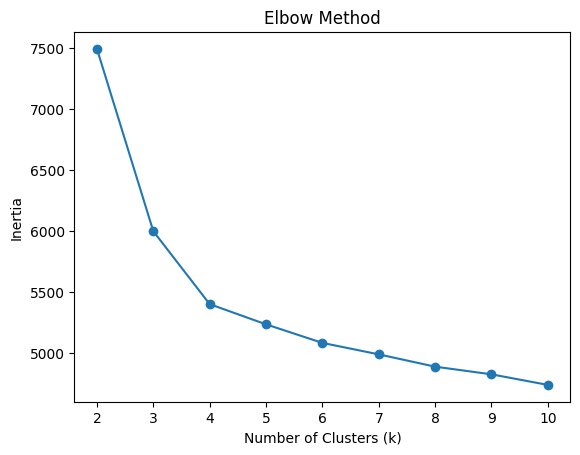

In [3]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []
k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

plt.plot(k_values, inertia, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

[np.float64(0.24689124364930504), np.float64(0.24913159273005936), np.float64(0.22834967586477461), np.float64(0.2111354726617098), np.float64(0.1637417166233525), np.float64(0.15972993650901343), np.float64(0.1491318440947286), np.float64(0.0758432312936301), np.float64(0.13365686381321443)]


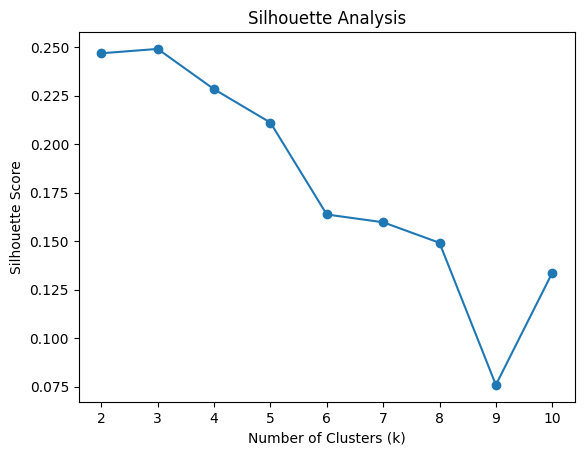

In [4]:
from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X, labels)
    silhouette_scores.append(score)

print(silhouette_scores)
plt.plot(k_values, silhouette_scores, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Analysis")
plt.show()

In [5]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
labels = kmeans.fit_predict(X)

final_inertia = kmeans.inertia_
final_silhouette = silhouette_score(X, labels)

print("Final Inertia:", final_inertia)
print("Final Silhouette Score:", final_silhouette)

Final Inertia: 5999.087738995322
Final Silhouette Score: 0.24913159273005936


In [6]:
import pandas as pd

df_clustered = df.copy()
df_clustered['Cluster'] = labels

# Mean (for numeric + encoded)
cluster_means = df_clustered.groupby('Cluster')[num_cols].mean()

# Mode (for categorical)
cluster_modes = df_clustered.groupby('Cluster')[cat_cols].agg(lambda x: x.mode()[0])

print(cluster_means)
print(cluster_modes)

         StudyHoursPerDay  SleepHoursPerNight  InternetUsageHours  \
Cluster                                                             
0                7.008440            6.478543            1.542598   
1                2.622357            5.585995            6.042179   
2                4.444114            7.352330            3.082298   

         AttendanceRate  ExtracurricularHoursPerWeek  \
Cluster                                                
0             92.014961                     1.042441   
1             66.675744                     4.263776   
2             81.582848                     3.987476   

         PhysicalActivityHoursPerWeek  PartTimeJobHoursPerWeek  StressLevel  
Cluster                                                                      
0                            2.138189                 1.173386     7.475591  
1                            1.976270                 6.672311     6.340046  
2                            3.914984                 4.24029

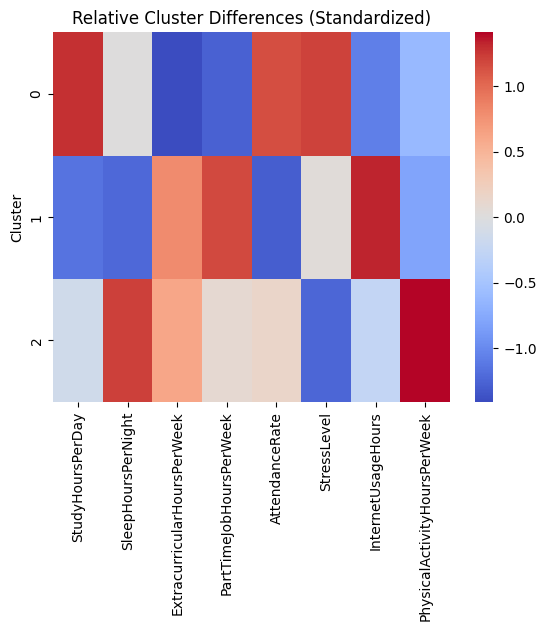

In [7]:
from sklearn.preprocessing import StandardScaler
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

top_features = [
    'StudyHoursPerDay',
    'SleepHoursPerNight',
    'ExtracurricularHoursPerWeek',
    'PartTimeJobHoursPerWeek',
    'AttendanceRate',
    'StressLevel',
    'InternetUsageHours',
    'PhysicalActivityHoursPerWeek'
]

# Extract data
data = cluster_means[top_features]

# Standardize (column-wise)
scaler = StandardScaler()
data_scaled = pd.DataFrame(
    scaler.fit_transform(data),
    index=data.index,
    columns=data.columns
)

# Plot heatmap
plt.figure()
sns.heatmap(data_scaled, annot=False, cmap="coolwarm", center=0)
plt.title("Relative Cluster Differences (Standardized)")
plt.show()

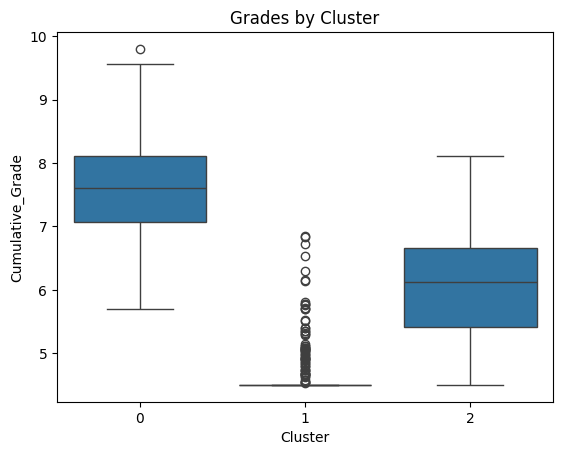

P-value: 0.0


In [8]:
from scipy.stats import f_oneway
sns.boxplot(x='Cluster', y='Cumulative_Grade', data=df_clustered)
plt.title("Grades by Cluster")
plt.show()



groups = [group['Cumulative_Grade'].values 
          for name, group in df_clustered.groupby('Cluster')]

f_stat, p_value = f_oneway(*groups)

print("P-value:", p_value)

In [9]:
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN
import numpy as np


pca = PCA(n_components=10)
X_db = pca.fit_transform(X)

configs = [
    (0.5, 5),
    (1.0, 5),
    (1.5, 10)
]

for eps, min_samples in configs:
    db = DBSCAN(eps=eps, min_samples=min_samples)
    labels = db.fit_predict(X_db)
    
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    noise_points = list(labels).count(-1)
    
    print(f"eps={eps}, min_samples={min_samples}")
    print("Clusters:", n_clusters)
    print("Noise points:", noise_points)
    print("-"*30)

eps=0.5, min_samples=5
Clusters: 0
Noise points: 1000
------------------------------
eps=1.0, min_samples=5
Clusters: 5
Noise points: 861
------------------------------
eps=1.5, min_samples=10
Clusters: 3
Noise points: 373
------------------------------


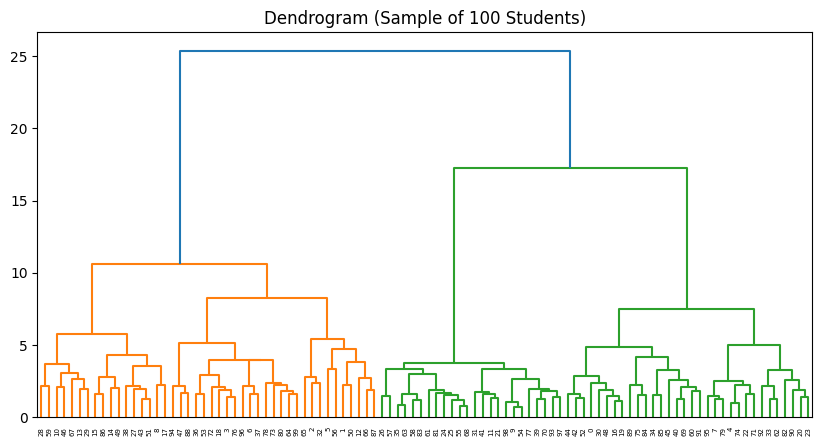

In [10]:
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

sample = X_db[:100]

Z = linkage(sample, method='ward')

plt.figure(figsize=(10, 5))
dendrogram(Z)
plt.title("Dendrogram (Sample of 100 Students)")
plt.show()